In [ ]:
# ============================================================
# CELL 1
# DATASET SETUP
# English: Brown Corpus
# Spanish: UD Spanish-GSD
# ============================================================

import nltk
import math
import random
import re

from collections import Counter, defaultdict

# ------------------------------------------------------------
# Download Brown Corpus
# ------------------------------------------------------------

nltk.download("brown")

from nltk.corpus import brown

# ------------------------------------------------------------
# ENGLISH DATA
# We use Brown Corpus and split it 80/20
# ------------------------------------------------------------

english_sentences = list(brown.tagged_sents())

# Remove very strange/empty sentences
english_sentences = [
    sentence
    for sentence in english_sentences
    if len(sentence) > 0
]

# Make result reproducible
random.seed(42)

random.shuffle(english_sentences)

english_split = int(0.8 * len(english_sentences))

english_train = english_sentences[:english_split]
english_test = english_sentences[english_split:]

print("English training sentences:", len(english_train))
print("English testing sentences :", len(english_test))


# ------------------------------------------------------------
# SPANISH DATA
# Download UD Spanish-GSD
# ------------------------------------------------------------

!git clone -q https://github.com/UniversalDependencies/UD_Spanish-GSD.git

# ------------------------------------------------------------
# Function to read CoNLL-U files
# ------------------------------------------------------------

def read_conllu(filename):

    sentences = []
    current_sentence = []

    with open(filename, "r", encoding="utf-8") as file:

        for line in file:

            line = line.strip()

            # Empty line = end of sentence
            if line == "":

                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []

                continue

            # Ignore comments
            if line.startswith("#"):
                continue

            parts = line.split("\t")

            # Normal token line has 10 columns
            if len(parts) != 10:
                continue

            token_id = parts[0]

            # Ignore multi-word token ranges such as 1-2
            if "-" in token_id or "." in token_id:
                continue

            token = {
                "id": token_id,
                "word": parts[1],
                "lemma": parts[2],
                "upos": parts[3],
                "xpos": parts[4],
                "feats": parts[5]
            }

            current_sentence.append(token)

    if current_sentence:
        sentences.append(current_sentence)

    return sentences


# ------------------------------------------------------------
# Load Spanish train/dev/test
# ------------------------------------------------------------

spanish_train = read_conllu(
    "UD_Spanish-GSD/es_gsd-ud-train.conllu"
)

spanish_dev = read_conllu(
    "UD_Spanish-GSD/es_gsd-ud-dev.conllu"
)

spanish_test = read_conllu(
    "UD_Spanish-GSD/es_gsd-ud-test.conllu"
)

print()
print("Spanish training sentences:", len(spanish_train))
print("Spanish development sentences:", len(spanish_dev))
print("Spanish testing sentences:", len(spanish_test))

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!


English training sentences: 45872
English testing sentences : 11468

Spanish training sentences: 14186
Spanish development sentences: 1400
Spanish testing sentences: 427


In [ ]:
# ============================================================
# CELL 2
# SPANISH POS + MORPHOLOGY PREPARATION
# ============================================================

# ------------------------------------------------------------
# Convert Spanish sentence into:
# [(word, UPOS)]
# ------------------------------------------------------------

def get_upos_sentence(sentence):

    return [
        (token["word"], token["upos"])
        for token in sentence
    ]


# ------------------------------------------------------------
# Create morphology-aware tag
#
# Example:
# NOUN + Gender=Fem + Number=Sing
# becomes:
# NOUN-Fem-Sg
#
# If gender/number is missing, we keep the UPOS tag.
# ------------------------------------------------------------

def get_morphology_tag(token):

    upos = token["upos"]
    feats = token["feats"]

    gender = None
    number = None

    if feats != "_":

        feature_list = feats.split("|")

        for feature in feature_list:

            if feature.startswith("Gender="):
                gender_value = feature.split("=")[1]

                if gender_value == "Fem":
                    gender = "Fem"

                elif gender_value == "Masc":
                    gender = "Masc"

            if feature.startswith("Number="):
                number_value = feature.split("=")[1]

                if number_value == "Sing":
                    number = "Sg"

                elif number_value == "Plur":
                    number = "Pl"

    tag = upos

    if gender is not None:
        tag += "-" + gender

    if number is not None:
        tag += "-" + number

    return tag


# ------------------------------------------------------------
# Convert sentence into morphology-aware format
# ------------------------------------------------------------

def get_morph_sentence(sentence):

    result = []

    for token in sentence:

        word = token["word"]
        tag = get_morphology_tag(token)

        result.append((word, tag))

    return result


# ------------------------------------------------------------
# Create all Spanish versions
# ------------------------------------------------------------

spanish_train_upos = [
    get_upos_sentence(sentence)
    for sentence in spanish_train
]

spanish_dev_upos = [
    get_upos_sentence(sentence)
    for sentence in spanish_dev
]

spanish_test_upos = [
    get_upos_sentence(sentence)
    for sentence in spanish_test
]


spanish_train_morph = [
    get_morph_sentence(sentence)
    for sentence in spanish_train
]

spanish_dev_morph = [
    get_morph_sentence(sentence)
    for sentence in spanish_dev
]

spanish_test_morph = [
    get_morph_sentence(sentence)
    for sentence in spanish_test
]


print("Spanish UPOS data prepared.")
print("Spanish morphology-aware data prepared.")

print()
print("Example:")
print(spanish_train_morph[0][:10])

Spanish UPOS data prepared.
Spanish morphology-aware data prepared.

Example:
[('Además', 'ADV'), ('se', 'PRON'), ('le', 'PRON-Sg'), ('pediría', 'VERB-Sg'), ('a', 'ADP'), ('las', 'DET-Fem-Pl'), ('empresas', 'NOUN-Fem-Pl'), ('interesadas', 'ADJ-Fem-Pl'), ('en', 'ADP'), ('prestar', 'VERB')]


In [ ]:
# ============================================================
# CELL 3
# TRIGRAM WORD SEGMENTATION + DYNAMIC PROGRAMMING
# ============================================================

# ------------------------------------------------------------
# Build word language model
# ------------------------------------------------------------

def build_word_model(sentences):

    word_counts = Counter()
    bigram_counts = Counter()
    trigram_counts = Counter()

    vocabulary = set()

    for sentence in sentences:

        words = []

        for item in sentence:

            # English sentence:
            # (word, tag)
            if isinstance(item, tuple):
                word = item[0]

            # Spanish token dictionary
            else:
                word = item["word"]

            word = word.lower()

            # We mainly want words made of letters
            if word.isalpha():

                words.append(word)
                word_counts[word] += 1
                vocabulary.add(word)

        # Add start symbols
        padded = [
            "<START>",
            "<START>"
        ] + words + ["<END>"]

        # Bigram counts
        for i in range(1, len(padded)):

            bigram_counts[
                (padded[i - 1], padded[i])
            ] += 1

        # Trigram counts
        for i in range(2, len(padded)):

            trigram_counts[
                (
                    padded[i - 2],
                    padded[i - 1],
                    padded[i]
                )
            ] += 1

    return (
        word_counts,
        bigram_counts,
        trigram_counts,
        vocabulary
    )


# ------------------------------------------------------------
# Trigram segmenter
# ------------------------------------------------------------

class TrigramSegmenter:

    def __init__(
        self,
        word_counts,
        bigram_counts,
        trigram_counts,
        vocabulary
    ):

        self.word_counts = word_counts
        self.bigram_counts = bigram_counts
        self.trigram_counts = trigram_counts
        self.vocabulary = vocabulary

        self.total_words = sum(word_counts.values())

        # Maximum word length from vocabulary
        if vocabulary:
            self.max_word_length = max(
                len(word)
                for word in vocabulary
            )
        else:
            self.max_word_length = 20


    # --------------------------------------------------------
    # Probability of a word
    # --------------------------------------------------------

    def word_probability(self, word):

        numerator = (
            self.word_counts[word]
            + 1
        )

        denominator = (
            self.total_words
            + len(self.vocabulary)
        )

        return numerator / denominator


    # --------------------------------------------------------
    # Probability of current word given previous 2 words
    # --------------------------------------------------------

    def trigram_probability(
        self,
        previous_previous,
        previous,
        current
    ):

        numerator = (
            self.trigram_counts[
                (
                    previous_previous,
                    previous,
                    current
                )
            ]
            + 1
        )

        denominator = (
            self.bigram_counts[
                (
                    previous_previous,
                    previous
                )
            ]
            + len(self.vocabulary)
            + 1
        )

        return numerator / denominator


    # --------------------------------------------------------
    # Find vocabulary words that match the current position
    # --------------------------------------------------------

    def get_candidates(self, text, position):

        candidates = []

        max_length = min(
            self.max_word_length,
            len(text) - position
        )

        for end in range(
            position + 1,
            position + max_length + 1
        ):

            word = text[position:end].lower()

            if word in self.vocabulary:

                candidates.append(word)

        return candidates


    # --------------------------------------------------------
    # DP / Viterbi segmentation
    # --------------------------------------------------------

    def segment(self, text):

        text = text.lower()

        n = len(text)

        if n == 0:
            return []


        # ----------------------------------------------------
        # DP state:
        #
        # (character_position,
        #  previous_previous_word,
        #  previous_word)
        #
        # value:
        # (score, words_so_far)
        # ----------------------------------------------------

        dp = {
            (
                0,
                "<START>",
                "<START>"
            ): (
                0.0,
                []
            )
        }


        for position in range(n + 1):

            current_states = [
                state
                for state in dp
                if state[0] == position
            ]

            for state in current_states:

                pos, prev_prev, prev = state

                score, words_so_far = dp[state]

                if pos == n:
                    continue


                candidates = self.get_candidates(
                    text,
                    pos
                )


                # If no vocabulary word matches,
                # take a single character as fallback.
                if not candidates:

                    candidates = [
                        text[pos:pos + 1]
                    ]


                for word in candidates:

                    new_position = (
                        pos + len(word)
                    )


                    # Word probability
                    word_prob = (
                        self.word_probability(word)
                    )


                    # Trigram probability
                    transition_prob = (
                        self.trigram_probability(
                            prev_prev,
                            prev,
                            word
                        )
                    )


                    new_score = (
                        score
                        + math.log(word_prob)
                        + math.log(transition_prob)
                    )


                    new_state = (
                        new_position,
                        prev,
                        word
                    )


                    if (
                        new_state not in dp
                        or
                        new_score > dp[new_state][0]
                    ):

                        dp[new_state] = (
                            new_score,
                            words_so_far + [word]
                        )


        # ----------------------------------------------------
        # Find best final state
        # ----------------------------------------------------

        best_score = float("-inf")
        best_words = None


        for state, value in dp.items():

            position, prev_prev, prev = state

            if position != n:
                continue

            score, words_so_far = value

            end_probability = (
                self.trigram_probability(
                    prev_prev,
                    prev,
                    "<END>"
                )
            )

            final_score = (
                score
                + math.log(end_probability)
            )


            if final_score > best_score:

                best_score = final_score
                best_words = words_so_far


        return best_words


# ------------------------------------------------------------
# Train English segmentation model
# ------------------------------------------------------------

(
    english_word_counts,
    english_bigram_counts,
    english_trigram_counts,
    english_vocabulary
) = build_word_model(english_train)


english_segmenter = TrigramSegmenter(
    english_word_counts,
    english_bigram_counts,
    english_trigram_counts,
    english_vocabulary
)


# ------------------------------------------------------------
# Train Spanish segmentation model
# ------------------------------------------------------------

(
    spanish_word_counts,
    spanish_bigram_counts,
    spanish_trigram_counts,
    spanish_vocabulary
) = build_word_model(spanish_train)


spanish_segmenter = TrigramSegmenter(
    spanish_word_counts,
    spanish_bigram_counts,
    spanish_trigram_counts,
    spanish_vocabulary
)


print("English vocabulary:", len(english_vocabulary))
print("Spanish vocabulary:", len(spanish_vocabulary))

print()
print("Segmentation models created successfully.")

English vocabulary: 36912
Spanish vocabulary: 39599

Segmentation models created successfully.


In [ ]:
# ============================================================
# CELL 4
# SEGMENTATION BASELINE + DEV TUNING + EVALUATION
# ============================================================


# ------------------------------------------------------------
# GREEDY LONGEST-MATCH BASELINE
# ------------------------------------------------------------

def greedy_longest_match(text, vocabulary):

    text = text.lower()

    result = []

    position = 0

    while position < len(text):

        best_word = None

        # Try longest word first
        for end in range(
            len(text),
            position,
            -1
        ):

            candidate = text[position:end]

            if candidate in vocabulary:

                best_word = candidate
                break


        # If nothing found, use one character
        if best_word is None:

            best_word = text[position:position + 1]


        result.append(best_word)

        position += len(best_word)


    return result


# ------------------------------------------------------------
# Gold words from English sentence
# ------------------------------------------------------------

def get_english_words(sentence):

    return [
        word.lower()
        for word, tag in sentence
        if word.isalpha()
    ]


# ------------------------------------------------------------
# Gold words from Spanish sentence
# ------------------------------------------------------------

def get_spanish_words(sentence):

    return [
        token["word"].lower()
        for token in sentence
        if token["word"].isalpha()
    ]


# ------------------------------------------------------------
# Boundary F1
#
# Example:
#
# the | quick | fox
#
# Boundaries are positions where a word ends.
# ------------------------------------------------------------

def get_boundaries(words):

    boundaries = set()

    position = 0

    for word in words:

        position += len(word)

        boundaries.add(position)

    return boundaries


def boundary_scores(gold_words, predicted_words):

    gold_boundaries = get_boundaries(
        gold_words
    )

    predicted_boundaries = get_boundaries(
        predicted_words
    )

    # Final boundary is always the end of sentence,
    # so remove it.
    if gold_boundaries:
        gold_boundaries.remove(
            max(gold_boundaries)
        )

    if predicted_boundaries:
        predicted_boundaries.remove(
            max(predicted_boundaries)
        )


    true_positive = len(
        gold_boundaries &
        predicted_boundaries
    )

    predicted_count = len(
        predicted_boundaries
    )

    gold_count = len(
        gold_boundaries
    )


    if predicted_count == 0:
        precision = 0.0
    else:
        precision = (
            true_positive /
            predicted_count
        )


    if gold_count == 0:
        recall = 0.0
    else:
        recall = (
            true_positive /
            gold_count
        )


    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = (
            2 * precision * recall
            / (precision + recall)
        )


    return precision, recall, f1


# ------------------------------------------------------------
# Exact segmentation accuracy
# ------------------------------------------------------------

def segmentation_exact_accuracy(
    segmenter,
    sentences,
    limit=None
):

    correct = 0
    total = 0

    if limit is not None:
        sentences = sentences[:limit]


    for sentence in sentences:

        gold_words = get_english_words(
            sentence
        )

        if len(gold_words) == 0:
            continue

        text = "".join(gold_words)

        predicted_words = segmenter.segment(
            text
        )

        if predicted_words == gold_words:
            correct += 1

        total += 1


    if total == 0:
        return 0.0

    return correct / total


# ------------------------------------------------------------
# Generic segmentation evaluation
# ------------------------------------------------------------

def evaluate_segmentation(
    segmenter,
    sentences,
    language="english",
    limit=100
):

    if limit is not None:
        sentences = sentences[:limit]


    exact_correct = 0
    total_sentences = 0

    precision_sum = 0.0
    recall_sum = 0.0
    f1_sum = 0.0


    for sentence in sentences:

        if language == "english":

            gold_words = get_english_words(
                sentence
            )

        else:

            gold_words = get_spanish_words(
                sentence
            )


        if not gold_words:
            continue


        text = "".join(gold_words)

        predicted_words = segmenter.segment(
            text
        )


        if predicted_words == gold_words:
            exact_correct += 1


        precision, recall, f1 = (
            boundary_scores(
                gold_words,
                predicted_words
            )
        )


        precision_sum += precision
        recall_sum += recall
        f1_sum += f1

        total_sentences += 1


    if total_sentences == 0:

        return {
            "exact_accuracy": 0,
            "precision": 0,
            "recall": 0,
            "f1": 0
        }


    return {

        "exact_accuracy":
            exact_correct / total_sentences,

        "precision":
            precision_sum / total_sentences,

        "recall":
            recall_sum / total_sentences,

        "f1":
            f1_sum / total_sentences
    }


# ------------------------------------------------------------
# DEV SET TUNING
#
# We tune maximum word length.
# ------------------------------------------------------------

def tune_max_word_length(
    segmenter,
    sentences,
    language,
    candidates
):

    best_length = None
    best_f1 = -1


    for length in candidates:

        segmenter.max_word_length = length

        result = evaluate_segmentation(
            segmenter,
            sentences,
            language=language,
            limit=50
        )

        print(
            "max_word_length =",
            length,
            "Dev F1 =",
            round(result["f1"], 4)
        )


        if result["f1"] > best_f1:

            best_f1 = result["f1"]
            best_length = length


    segmenter.max_word_length = best_length

    return best_length, best_f1


print("Tuning English segmentation on DEV-like tuning split...")
print()

# English has no official dev split because assignment
# specifically asks for Brown 80/20.
# We use a small part of the training data as tuning data.

english_tuning = english_train[:200]

english_best_length, english_dev_f1 = (
    tune_max_word_length(
        english_segmenter,
        english_tuning,
        "english",
        [10, 15, 20, 25, 30]
    )
)

print()
print(
    "Best English max word length:",
    english_best_length
)


print()
print("Tuning Spanish segmentation on official DEV set...")
print()

spanish_best_length, spanish_dev_f1 = (
    tune_max_word_length(
        spanish_segmenter,
        spanish_dev,
        "spanish",
        [10, 15, 20, 25, 30]
    )
)

print()
print(
    "Best Spanish max word length:",
    spanish_best_length
)


# ------------------------------------------------------------
# FINAL TEST EVALUATION
#
# We use a manageable number first.
# Change 100 to None if you want the complete test set.
# ------------------------------------------------------------

TEST_LIMIT = 100


english_seg_result = evaluate_segmentation(
    english_segmenter,
    english_test,
    language="english",
    limit=TEST_LIMIT
)


spanish_seg_result = evaluate_segmentation(
    spanish_segmenter,
    spanish_test,
    language="spanish",
    limit=TEST_LIMIT
)


print()
print("========== SEGMENTATION RESULTS ==========")

print()
print("English:")
print(
    "Exact accuracy:",
    round(
        english_seg_result["exact_accuracy"] * 100,
        2
    ),
    "%"
)

print(
    "Boundary Precision:",
    round(
        english_seg_result["precision"] * 100,
        2
    ),
    "%"
)

print(
    "Boundary Recall:",
    round(
        english_seg_result["recall"] * 100,
        2
    ),
    "%"
)

print(
    "Boundary F1:",
    round(
        english_seg_result["f1"] * 100,
        2
    ),
    "%"
)


print()
print("Spanish:")

print(
    "Exact accuracy:",
    round(
        spanish_seg_result["exact_accuracy"] * 100,
        2
    ),
    "%"
)

print(
    "Boundary Precision:",
    round(
        spanish_seg_result["precision"] * 100,
        2
    ),
    "%"
)

print(
    "Boundary Recall:",
    round(
        spanish_seg_result["recall"] * 100,
        2
    ),
    "%"
)

print(
    "Boundary F1:",
    round(
        spanish_seg_result["f1"] * 100,
        2
    ),
    "%"
)


# ------------------------------------------------------------
# BASELINE SEGMENTATION RESULTS
# ------------------------------------------------------------

def evaluate_greedy_segmentation(
    sentences,
    vocabulary,
    language="english",
    limit=100
):

    if limit is not None:
        sentences = sentences[:limit]


    exact_correct = 0
    total = 0


    for sentence in sentences:

        if language == "english":

            gold_words = get_english_words(
                sentence
            )

        else:

            gold_words = get_spanish_words(
                sentence
            )


        if not gold_words:
            continue


        text = "".join(gold_words)

        predicted = greedy_longest_match(
            text,
            vocabulary
        )


        if predicted == gold_words:
            exact_correct += 1


        total += 1


    if total == 0:
        return 0.0


    return exact_correct / total


english_greedy_accuracy = (
    evaluate_greedy_segmentation(
        english_test,
        english_vocabulary,
        "english",
        TEST_LIMIT
    )
)


spanish_greedy_accuracy = (
    evaluate_greedy_segmentation(
        spanish_test,
        spanish_vocabulary,
        "spanish",
        TEST_LIMIT
    )
)


print()
print("========== SEGMENTATION BASELINE ==========")

print(
    "English greedy accuracy:",
    round(
        english_greedy_accuracy * 100,
        2
    ),
    "%"
)

print(
    "English DP improvement:",
    round(
        (
            english_seg_result["exact_accuracy"]
            - english_greedy_accuracy
        ) * 100,
        2
    ),
    "percentage points"
)


print()

print(
    "Spanish greedy accuracy:",
    round(
        spanish_greedy_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Spanish DP improvement:",
    round(
        (
            spanish_seg_result["exact_accuracy"]
            - spanish_greedy_accuracy
        ) * 100,
        2
    ),
    "percentage points"
)

Tuning English segmentation on DEV-like tuning split...

max_word_length = 10 Dev F1 = 0.9372
max_word_length = 15 Dev F1 = 0.9751
max_word_length = 20 Dev F1 = 0.9767
max_word_length = 25 Dev F1 = 0.9767
max_word_length = 30 Dev F1 = 0.9767

Best English max word length: 20

Tuning Spanish segmentation on official DEV set...

max_word_length = 10 Dev F1 = 0.8616
max_word_length = 15 Dev F1 = 0.8938
max_word_length = 20 Dev F1 = 0.8945
max_word_length = 25 Dev F1 = 0.8945
max_word_length = 30 Dev F1 = 0.8945

Best Spanish max word length: 20

========== SEGMENTATION RESULTS ==========

English:
Exact accuracy: 62.63 %
Boundary Precision: 94.48 %
Boundary Recall: 98.13 %
Boundary F1: 96.08 %

Spanish:
Exact accuracy: 18.0 %
Boundary Precision: 86.48 %
Boundary Recall: 95.98 %
Boundary F1: 90.35 %

========== SEGMENTATION BASELINE ==========
English greedy accuracy: 13.13 %
English DP improvement: 49.49 percentage points

Spanish greedy accuracy: 4.0 %
Spanish DP improvement: 14.0 percen

In [ ]:
# ============================================================
# CELL 5
# TRIGRAM POS TAGGER
# Emission + Trigram Transition + DP/Viterbi
# ============================================================


class TrigramPOSTagger:

    def __init__(self):

        self.word_tag_counts = Counter()

        self.tag_counts = Counter()

        self.bigram_tag_counts = Counter()

        self.trigram_tag_counts = Counter()

        self.tags = set()

        self.vocabulary = set()


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    def train(self, sentences):

        for sentence in sentences:

            tags = []

            for word, tag in sentence:

                word = word.lower()

                tags.append(tag)

                self.word_tag_counts[
                    (word, tag)
                ] += 1

                self.tag_counts[tag] += 1

                self.tags.add(tag)

                self.vocabulary.add(word)


            padded_tags = (
                ["<START>", "<START>"]
                + tags
                + ["<END>"]
            )


            # Bigram counts
            for i in range(
                1,
                len(padded_tags)
            ):

                self.bigram_tag_counts[
                    (
                        padded_tags[i - 1],
                        padded_tags[i]
                    )
                ] += 1


            # Trigram counts
            for i in range(
                2,
                len(padded_tags)
            ):

                self.trigram_tag_counts[
                    (
                        padded_tags[i - 2],
                        padded_tags[i - 1],
                        padded_tags[i]
                    )
                ] += 1


    # --------------------------------------------------------
    # EMISSION PROBABILITY
    #
    # P(word | tag)
    # --------------------------------------------------------

    def emission_probability(
        self,
        word,
        tag
    ):

        numerator = (
            self.word_tag_counts[
                (word, tag)
            ]
            + 1
        )

        denominator = (
            self.tag_counts[tag]
            + len(self.vocabulary)
        )

        return numerator / denominator


    # --------------------------------------------------------
    # TRIGRAM TRANSITION PROBABILITY
    #
    # P(current_tag |
    #   previous_previous_tag,
    #   previous_tag)
    # --------------------------------------------------------

    def transition_probability(
        self,
        previous_previous_tag,
        previous_tag,
        current_tag
    ):

        numerator = (
            self.trigram_tag_counts[
                (
                    previous_previous_tag,
                    previous_tag,
                    current_tag
                )
            ]
            + 1
        )


        denominator = (
            self.bigram_tag_counts[
                (
                    previous_previous_tag,
                    previous_tag
                )
            ]
            + len(self.tags)
            + 1
        )


        return numerator / denominator


    # --------------------------------------------------------
    # GET POSSIBLE TAGS FOR A WORD
    #
    # This makes Brown much faster.
    # --------------------------------------------------------

    def get_possible_tags(self, word):

        possible_tags = set()

        for tag in self.tags:

            if (
                self.word_tag_counts[
                    (word, tag)
                ] > 0
            ):

                possible_tags.add(tag)


        # Unknown word:
        # try every tag
        if not possible_tags:

            possible_tags = self.tags


        return possible_tags


    # --------------------------------------------------------
    # VITERBI / DP TAGGING
    # --------------------------------------------------------

    def tag(self, words):

        words = [
            word.lower()
            for word in words
        ]


        if len(words) == 0:
            return []


        # State:
        # (previous_previous_tag, previous_tag)
        #
        # Value:
        # (score, tag sequence)

        dp = {

            (
                "<START>",
                "<START>"
            ): (
                0.0,
                []
            )
        }


        for word in words:

            new_dp = {}


            possible_tags = (
                self.get_possible_tags(word)
            )


            for (
                prev_prev,
                prev
            ), (
                score,
                tag_sequence
            ) in dp.items():


                for tag in possible_tags:


                    emission = math.log(
                        self.emission_probability(
                            word,
                            tag
                        )
                    )


                    transition = math.log(
                        self.transition_probability(
                            prev_prev,
                            prev,
                            tag
                        )
                    )


                    new_score = (
                        score
                        + emission
                        + transition
                    )


                    state = (
                        prev,
                        tag
                    )


                    if (
                        state not in new_dp
                        or
                        new_score > new_dp[state][0]
                    ):

                        new_dp[state] = (

                            new_score,

                            tag_sequence + [tag]
                        )


            dp = new_dp


        # ----------------------------------------------------
        # Add END probability
        # ----------------------------------------------------

        best_score = float("-inf")

        best_tags = None


        for (
            prev_prev,
            prev
        ), (
            score,
            tag_sequence
        ) in dp.items():


            end_probability = (
                self.transition_probability(
                    prev_prev,
                    prev,
                    "<END>"
                )
            )


            final_score = (
                score
                + math.log(end_probability)
            )


            if final_score > best_score:

                best_score = final_score

                best_tags = tag_sequence


        return best_tags


# ============================================================
# ENGLISH TAGGER
# ============================================================

english_tagger = TrigramPOSTagger()

english_tagger.train(
    english_train
)


# ============================================================
# SPANISH NORMAL UPOS TAGGER
# ============================================================

spanish_upos_tagger = TrigramPOSTagger()

spanish_upos_tagger.train(
    spanish_train_upos
)


# ============================================================
# SPANISH MORPHOLOGY-AWARE TAGGER
# ============================================================

spanish_morph_tagger = TrigramPOSTagger()

spanish_morph_tagger.train(
    spanish_train_morph
)


print("English tagger trained.")
print("Spanish UPOS tagger trained.")
print("Spanish morphology-aware tagger trained.")

print()
print("English tags:", len(english_tagger.tags))
print("Spanish UPOS tags:", len(spanish_upos_tagger.tags))
print(
    "Spanish morphology tags:",
    len(spanish_morph_tagger.tags)
)

English tagger trained.
Spanish UPOS tagger trained.
Spanish morphology-aware tagger trained.

English tags: 450
Spanish UPOS tags: 17
Spanish morphology tags: 86


In [ ]:
# ============================================================
# CELL 6
# MOST-FREQUENT-TAG BASELINE + POS EVALUATION
# ============================================================


# ------------------------------------------------------------
# MOST FREQUENT TAG BASELINE
# ------------------------------------------------------------

class MostFrequentTagger:

    def __init__(self):

        self.word_tag_counts = defaultdict(
            Counter
        )

        self.global_tag_counts = Counter()

        self.default_tag = None


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    def train(self, sentences):

        for sentence in sentences:

            for word, tag in sentence:

                word = word.lower()

                self.word_tag_counts[
                    word
                ][tag] += 1

                self.global_tag_counts[
                    tag
                ] += 1


        if self.global_tag_counts:

            self.default_tag = (
                self.global_tag_counts
                .most_common(1)[0][0]
            )


    # --------------------------------------------------------
    # TAG
    # --------------------------------------------------------

    def tag(self, words):

        result = []


        for word in words:

            word = word.lower()


            if word in self.word_tag_counts:

                tag = (
                    self.word_tag_counts[word]
                    .most_common(1)[0][0]
                )

            else:

                tag = self.default_tag


            result.append(tag)


        return result


# ============================================================
# CREATE BASELINES
# ============================================================

english_baseline = MostFrequentTagger()

english_baseline.train(
    english_train
)


spanish_baseline = MostFrequentTagger()

spanish_baseline.train(
    spanish_train_upos
)


# ------------------------------------------------------------
# POS evaluation
# ------------------------------------------------------------

def evaluate_pos_tagger(
    tagger,
    test_sentences,
    limit=None
):

    if limit is not None:

        test_sentences = (
            test_sentences[:limit]
        )


    correct = 0
    total = 0


    for sentence in test_sentences:

        words = [
            item[0]
            for item in sentence
        ]

        gold_tags = [
            item[1]
            for item in sentence
        ]


        predicted_tags = tagger.tag(
            words
        )


        for gold, predicted in zip(
            gold_tags,
            predicted_tags
        ):

            if gold == predicted:
                correct += 1

            total += 1


    if total == 0:
        return 0.0


    return correct / total


# ------------------------------------------------------------
# Spanish UPOS evaluation
# ------------------------------------------------------------

def evaluate_spanish_upos(
    tagger,
    test_sentences,
    limit=None
):

    if limit is not None:

        test_sentences = (
            test_sentences[:limit]
        )


    correct = 0
    total = 0


    for sentence in test_sentences:

        words = [
            item[0]
            for item in sentence
        ]

        gold_tags = [
            item[1]
            for item in sentence
        ]


        predicted_tags = tagger.tag(
            words
        )


        for gold, predicted in zip(
            gold_tags,
            predicted_tags
        ):

            # Convert morphology tag
            # back to UPOS.
            predicted_upos = (
                predicted.split("-")[0]
            )


            if gold == predicted_upos:

                correct += 1


            total += 1


    if total == 0:
        return 0.0


    return correct / total


# ============================================================
# EVALUATE
# ============================================================

POS_TEST_LIMIT = 300


english_model_accuracy = (
    evaluate_pos_tagger(
        english_tagger,
        english_test,
        POS_TEST_LIMIT
    )
)


english_baseline_accuracy = (
    evaluate_pos_tagger(
        english_baseline,
        english_test,
        POS_TEST_LIMIT
    )
)


spanish_upos_accuracy = (
    evaluate_pos_tagger(
        spanish_upos_tagger,
        spanish_test_upos,
        POS_TEST_LIMIT
    )
)


spanish_baseline_accuracy = (
    evaluate_pos_tagger(
        spanish_baseline,
        spanish_test_upos,
        POS_TEST_LIMIT
    )
)


spanish_morph_upos_accuracy = (
    evaluate_spanish_upos(
        spanish_morph_tagger,
        spanish_test_morph,
        POS_TEST_LIMIT
    )
)


# Exact morphology-aware accuracy
spanish_morph_exact_accuracy = (
    evaluate_pos_tagger(
        spanish_morph_tagger,
        spanish_test_morph,
        POS_TEST_LIMIT
    )
)


# ============================================================
# PRINT RESULTS
# ============================================================

print("========== POS RESULTS ==========")

print()

print(
    "English Trigram + DP:",
    round(
        english_model_accuracy * 100,
        2
    ),
    "%"
)

print(
    "English Most-Frequent-Tag:",
    round(
        english_baseline_accuracy * 100,
        2
    ),
    "%"
)

print(
    "English improvement:",
    round(
        (
            english_model_accuracy
            - english_baseline_accuracy
        ) * 100,
        2
    ),
    "percentage points"
)


print()

print(
    "Spanish Normal UPOS:",
    round(
        spanish_upos_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Spanish Most-Frequent-Tag:",
    round(
        spanish_baseline_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Spanish normal model improvement:",
    round(
        (
            spanish_upos_accuracy
            - spanish_baseline_accuracy
        ) * 100,
        2
    ),
    "percentage points"
)


print()

print(
    "Spanish Morphology-aware UPOS:",
    round(
        spanish_morph_upos_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Spanish Morphology-aware exact:",
    round(
        spanish_morph_exact_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Agreement-aware UPOS change:",
    round(
        (
            spanish_morph_upos_accuracy
            - spanish_upos_accuracy
        ) * 100,
        2
    ),
    "percentage points"
)

========== POS RESULTS ==========

English Trigram + DP: 93.33 %
English Most-Frequent-Tag: 89.52 %
English improvement: 3.82 percentage points

Spanish Normal UPOS: 93.25 %
Spanish Most-Frequent-Tag: 89.77 %
Spanish normal model improvement: 3.48 percentage points

Spanish Morphology-aware UPOS: 46.54 %
Spanish Morphology-aware exact: 90.93 %
Agreement-aware UPOS change: -46.71 percentage points


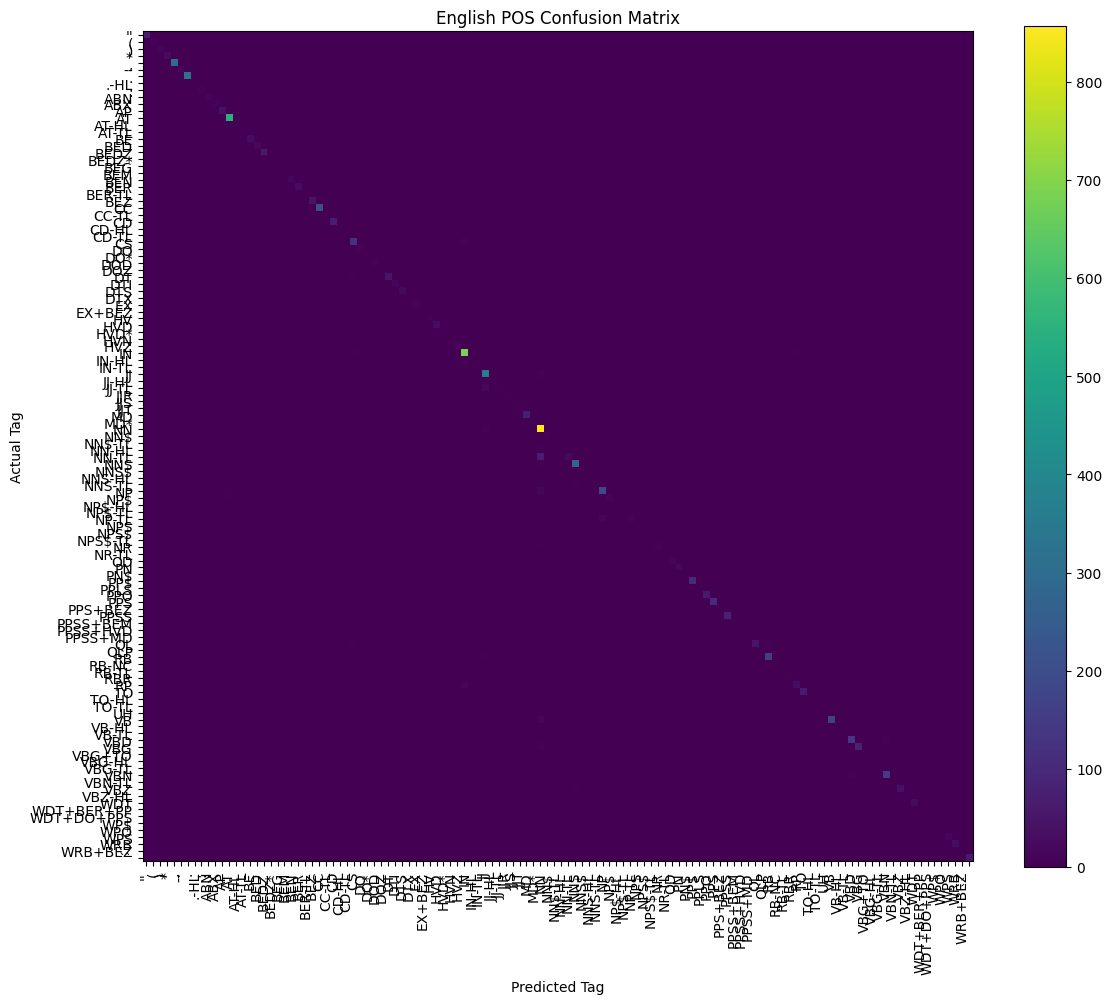

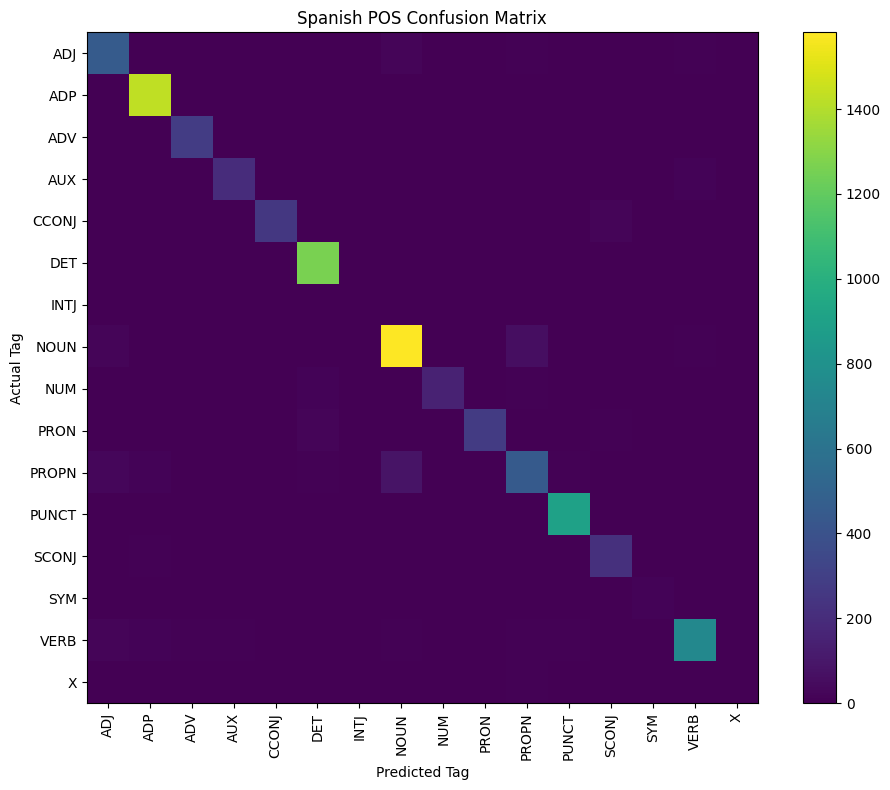

In [ ]:
# ============================================================
# CELL 7
# CONFUSION MATRICES
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Collect English predictions
# ------------------------------------------------------------

english_actual = []
english_predicted = []


for sentence in english_test[:POS_TEST_LIMIT]:

    words = [
        item[0]
        for item in sentence
    ]

    gold_tags = [
        item[1]
        for item in sentence
    ]


    predicted_tags = (
        english_tagger.tag(words)
    )


    for gold, predicted in zip(
        gold_tags,
        predicted_tags
    ):

        english_actual.append(gold)
        english_predicted.append(predicted)


# ------------------------------------------------------------
# English confusion matrix
# ------------------------------------------------------------

english_labels = sorted(
    set(english_actual)
    |
    set(english_predicted)
)


english_cm = confusion_matrix(
    english_actual,
    english_predicted,
    labels=english_labels
)


plt.figure(
    figsize=(12, 10)
)

plt.imshow(
    english_cm,
    interpolation="nearest"
)

plt.title(
    "English POS Confusion Matrix"
)

plt.xlabel(
    "Predicted Tag"
)

plt.ylabel(
    "Actual Tag"
)

plt.xticks(
    range(len(english_labels)),
    english_labels,
    rotation=90
)

plt.yticks(
    range(len(english_labels)),
    english_labels
)

plt.colorbar()

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Spanish UPOS predictions
# ------------------------------------------------------------

spanish_actual = []
spanish_predicted = []


for sentence in spanish_test_upos[:POS_TEST_LIMIT]:

    words = [
        item[0]
        for item in sentence
    ]

    gold_tags = [
        item[1]
        for item in sentence
    ]


    predicted_morph_tags = (
        spanish_morph_tagger.tag(words)
    )


    predicted_tags = [
        tag.split("-")[0]
        for tag in predicted_morph_tags
    ]


    for gold, predicted in zip(
        gold_tags,
        predicted_tags
    ):

        spanish_actual.append(gold)
        spanish_predicted.append(predicted)


# ------------------------------------------------------------
# Spanish confusion matrix
# ------------------------------------------------------------

spanish_labels = sorted(
    set(spanish_actual)
    |
    set(spanish_predicted)
)


spanish_cm = confusion_matrix(
    spanish_actual,
    spanish_predicted,
    labels=spanish_labels
)


plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    spanish_cm,
    interpolation="nearest"
)

plt.title(
    "Spanish POS Confusion Matrix"
)

plt.xlabel(
    "Predicted Tag"
)

plt.ylabel(
    "Actual Tag"
)

plt.xticks(
    range(len(spanish_labels)),
    spanish_labels,
    rotation=90
)

plt.yticks(
    range(len(spanish_labels)),
    spanish_labels
)

plt.colorbar()

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# CELL 8
# ERROR-SOURCE BREAKDOWN
#
# Segmentation-caused errors
# VS
# Genuine POS errors
# ============================================================


# ------------------------------------------------------------
# Align predicted words with gold words
#
# We consider a word correctly aligned if the predicted
# word exactly matches the gold word at the same position.
#
# If the segmentation changes the word boundaries, that
# word is counted as segmentation-caused.
# ------------------------------------------------------------

def analyze_error_sources(
    segmenter,
    pos_tagger,
    sentences,
    language="english",
    limit=50
):

    if limit is not None:

        sentences = sentences[:limit]


    segmentation_caused = 0
    genuine_pos_errors = 0

    correct_tags = 0

    total_gold_words = 0


    for sentence in sentences:


        # ----------------------------------------------------
        # GOLD WORDS + GOLD TAGS
        # ----------------------------------------------------

        if language == "english":

            gold_words = [
                item[0].lower()
                for item in sentence
                if item[0].isalpha()
            ]

            gold_tags = [
                item[1]
                for item in sentence
                if item[0].isalpha()
            ]

        else:

            gold_words = [
                item["word"].lower()
                for item in sentence
                if item["word"].isalpha()
            ]

            gold_tags = [
                item["upos"]
                for item in sentence
                if item["word"].isalpha()
            ]


        if not gold_words:
            continue


        # ----------------------------------------------------
        # REMOVE SPACES
        # ----------------------------------------------------

        text = "".join(gold_words)


        # ----------------------------------------------------
        # SEGMENT
        # ----------------------------------------------------

        predicted_words = (
            segmenter.segment(text)
        )


        # ----------------------------------------------------
        # POS TAG THE PREDICTED SEGMENTATION
        # ----------------------------------------------------

        predicted_tags = (
            pos_tagger.tag(
                predicted_words
            )
        )


        # For Spanish morphology model,
        # convert morphology tags to UPOS.
        if language == "spanish":

            predicted_tags = [
                tag.split("-")[0]
                for tag in predicted_tags
            ]


        # ----------------------------------------------------
        # COMPARE WORDS
        # ----------------------------------------------------

        i = 0

        while i < len(gold_words):

            total_gold_words += 1


            # Correct word exists at same position
            if (
                i < len(predicted_words)
                and
                predicted_words[i]
                == gold_words[i]
            ):


                # Word is correctly segmented.
                # Therefore a wrong tag is a genuine POS error.

                if (
                    i < len(predicted_tags)
                    and
                    predicted_tags[i]
                    == gold_tags[i]
                ):

                    correct_tags += 1

                else:

                    genuine_pos_errors += 1


                i += 1


            else:

                # Word was not produced correctly
                # because segmentation is wrong.

                segmentation_caused += 1

                i += 1


    total_tagging_errors = (
        segmentation_caused
        + genuine_pos_errors
    )


    if total_tagging_errors == 0:

        segmentation_percentage = 0.0
        genuine_percentage = 0.0

    else:

        segmentation_percentage = (
            segmentation_caused
            / total_tagging_errors
            * 100
        )

        genuine_percentage = (
            genuine_pos_errors
            / total_tagging_errors
            * 100
        )


    return {

        "total_words":
            total_gold_words,

        "correct_tags":
            correct_tags,

        "segmentation_caused":
            segmentation_caused,

        "genuine_pos_errors":
            genuine_pos_errors,

        "total_errors":
            total_tagging_errors,

        "segmentation_percentage":
            segmentation_percentage,

        "genuine_percentage":
            genuine_percentage
    }


# ============================================================
# ENGLISH
# ============================================================

english_error_analysis = (
    analyze_error_sources(
        english_segmenter,
        english_tagger,
        english_test,
        language="english",
        limit=50
    )
)


# ============================================================
# SPANISH
# ============================================================

spanish_error_analysis = (
    analyze_error_sources(
        spanish_segmenter,
        spanish_morph_tagger,
        spanish_test,
        language="spanish",
        limit=50
    )
)


# ============================================================
# PRINT
# ============================================================

print("========== ERROR SOURCE ANALYSIS ==========")

print()

print("ENGLISH")

print(
    "Total gold words:",
    english_error_analysis["total_words"]
)

print(
    "Correct POS tags:",
    english_error_analysis["correct_tags"]
)

print(
    "Segmentation-caused errors:",
    english_error_analysis[
        "segmentation_caused"
    ]
)

print(
    "Genuine POS errors:",
    english_error_analysis[
        "genuine_pos_errors"
    ]
)

print(
    "Total errors:",
    english_error_analysis[
        "total_errors"
    ]
)

print(
    "Percentage caused by segmentation:",
    round(
        english_error_analysis[
            "segmentation_percentage"
        ],
        2
    ),
    "%"
)

print(
    "Percentage genuine POS errors:",
    round(
        english_error_analysis[
            "genuine_percentage"
        ],
        2
    ),
    "%"
)


print()
print("SPANISH")

print(
    "Total gold words:",
    spanish_error_analysis["total_words"]
)

print(
    "Correct POS tags:",
    spanish_error_analysis["correct_tags"]
)

print(
    "Segmentation-caused errors:",
    spanish_error_analysis[
        "segmentation_caused"
    ]
)

print(
    "Genuine POS errors:",
    spanish_error_analysis[
        "genuine_pos_errors"
    ]
)

print(
    "Total errors:",
    spanish_error_analysis[
        "total_errors"
    ]
)

print(
    "Percentage caused by segmentation:",
    round(
        spanish_error_analysis[
            "segmentation_percentage"
        ],
        2
    ),
    "%"
)

print(
    "Percentage genuine POS errors:",
    round(
        spanish_error_analysis[
            "genuine_percentage"
        ],
        2
    ),
    "%"
)

========== ERROR SOURCE ANALYSIS ==========

ENGLISH
Total gold words: 895
Correct POS tags: 668
Segmentation-caused errors: 183
Genuine POS errors: 44
Total errors: 227
Percentage caused by segmentation: 80.62 %
Percentage genuine POS errors: 19.38 %

SPANISH
Total gold words: 1054
Correct POS tags: 337
Segmentation-caused errors: 703
Genuine POS errors: 14
Total errors: 717
Percentage caused by segmentation: 98.05 %
Percentage genuine POS errors: 1.95 %


In [ ]:
# ============================================================
# CELL 9
# REQUIRED SAMPLE STRINGS + OWN EXAMPLES
# ============================================================


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def run_full_pipeline(
    text,
    segmenter,
    tagger
):

    print("Input:")
    print(text)

    print()

    # Step 1: segmentation
    words = segmenter.segment(text)

    print("Segmentation:")
    print(words)

    print()

    # Step 2: POS tagging
    tags = tagger.tag(words)

    print("POS tagging:")

    result = list(
        zip(words, tags)
    )

    print(result)

    print()
    print("-" * 60)

    return result


# ============================================================
# REQUIRED ENGLISH EXAMPLE
# ============================================================

print("REQUIRED ENGLISH EXAMPLE")

english_sample = (
    "thequickbrownfoxjumpsoverthelazydog"
)

english_sample_result = (
    run_full_pipeline(
        english_sample,
        english_segmenter,
        english_tagger
    )
)


# ============================================================
# REQUIRED SPANISH EXAMPLE 1
# ============================================================

print("REQUIRED SPANISH EXAMPLE 1")

spanish_sample_1 = (
    "mispadrespuedenviajar"
)

spanish_sample_1_result = (
    run_full_pipeline(
        spanish_sample_1,
        spanish_segmenter,
        spanish_morph_tagger
    )
)


# ============================================================
# REQUIRED SPANISH EXAMPLE 2
# ============================================================

print("REQUIRED SPANISH EXAMPLE 2")

spanish_sample_2 = (
    "elcielodespejadoesazul"
)

spanish_sample_2_result = (
    run_full_pipeline(
        spanish_sample_2,
        spanish_segmenter,
        spanish_morph_tagger
    )
)


# ============================================================
# OWN ENGLISH EXAMPLE
# ============================================================

print("OWN ENGLISH EXAMPLE")

own_english = (
    "shequicklyruns"
)

run_full_pipeline(
    own_english,
    english_segmenter,
    english_tagger
)


# ============================================================
# OWN SPANISH EXAMPLE
# ============================================================

print("OWN SPANISH EXAMPLE")

own_spanish = (
    "lascasasblancassonbonitas"
)

run_full_pipeline(
    own_spanish,
    spanish_segmenter,
    spanish_morph_tagger
)

REQUIRED ENGLISH EXAMPLE
Input:
thequickbrownfoxjumpsoverthelazydog

Segmentation:
['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS tagging:
[('the', 'AT'), ('quick', 'JJ'), ('brown', 'JJ'), ('fox', 'NN'), ('jumps', 'NNS'), ('over', 'IN'), ('the', 'AT'), ('lazy', 'JJ'), ('dog', 'NN')]

------------------------------------------------------------
REQUIRED SPANISH EXAMPLE 1
Input:
mispadrespuedenviajar

Segmentation:
['mis', 'padres', 'pueden', 'viajar']

POS tagging:
[('mis', 'DET-Pl'), ('padres', 'NOUN-Masc-Pl'), ('pueden', 'AUX-Pl'), ('viajar', 'VERB')]

------------------------------------------------------------
REQUIRED SPANISH EXAMPLE 2
Input:
elcielodespejadoesazul

Segmentation:
['el', 'cielo', 'des', 'pe', 'j', 'ado', 'es', 'azul']

POS tagging:
[('el', 'DET-Masc-Sg'), ('cielo', 'NOUN-Masc-Sg'), ('des', 'ADP'), ('pe', 'PROPN'), ('j', 'PROPN'), ('ado', 'PROPN-Masc-Sg'), ('es', 'AUX-Sg'), ('azul', 'NOUN-Sg')]

------------------------------------------

[('las', 'DET-Fem-Pl'),
 ('casas', 'NOUN-Fem-Pl'),
 ('blancas', 'ADJ-Fem-Pl'),
 ('son', 'AUX-Pl'),
 ('bonita', 'ADJ-Fem-Sg'),
 ('s', 'PROPN')]

In [ ]:
# ============================================================
# CELL 10
# FINAL COMPARISON + REPORT NUMBERS
# ============================================================


print("=" * 70)
print("FINAL COMPARISON")
print("=" * 70)


# ------------------------------------------------------------
# 1. SEGMENTATION
# ------------------------------------------------------------

print()
print("1. WORD SEGMENTATION")
print("-" * 50)

print(
    "English DP exact accuracy:",
    round(
        english_seg_result[
            "exact_accuracy"
        ] * 100,
        2
    ),
    "%"
)

print(
    "English greedy baseline:",
    round(
        english_greedy_accuracy * 100,
        2
    ),
    "%"
)

print(
    "English DP improvement:",
    round(
        (
            english_seg_result[
                "exact_accuracy"
            ]
            - english_greedy_accuracy
        ) * 100,
        2
    ),
    "percentage points"
)


print()

print(
    "Spanish DP exact accuracy:",
    round(
        spanish_seg_result[
            "exact_accuracy"
        ] * 100,
        2
    ),
    "%"
)

print(
    "Spanish greedy baseline:",
    round(
        spanish_greedy_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Spanish DP improvement:",
    round(
        (
            spanish_seg_result[
                "exact_accuracy"
            ]
            - spanish_greedy_accuracy
        ) * 100,
        2
    ),
    "percentage points"
)


# ------------------------------------------------------------
# 2. POS
# ------------------------------------------------------------

print()
print("2. POS TAGGING")
print("-" * 50)

print(
    "English Trigram + DP:",
    round(
        english_model_accuracy * 100,
        2
    ),
    "%"
)

print(
    "English Most-Frequent-Tag:",
    round(
        english_baseline_accuracy * 100,
        2
    ),
    "%"
)

print(
    "English improvement:",
    round(
        (
            english_model_accuracy
            - english_baseline_accuracy
        ) * 100,
        2
    ),
    "percentage points"
)


print()

print(
    "Spanish Normal UPOS:",
    round(
        spanish_upos_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Spanish Most-Frequent-Tag:",
    round(
        spanish_baseline_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Spanish normal improvement:",
    round(
        (
            spanish_upos_accuracy
            - spanish_baseline_accuracy
        ) * 100,
        2
    ),
    "percentage points"
)


# ------------------------------------------------------------
# 3. MORPHOLOGY
# ------------------------------------------------------------

print()
print("3. MORPHOLOGY-AWARE TAGGING")
print("-" * 50)

print(
    "Spanish normal UPOS accuracy:",
    round(
        spanish_upos_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Spanish morphology-aware UPOS:",
    round(
        spanish_morph_upos_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Spanish morphology-aware exact:",
    round(
        spanish_morph_exact_accuracy * 100,
        2
    ),
    "%"
)

morph_change = (
    spanish_morph_upos_accuracy
    - spanish_upos_accuracy
) * 100


print(
    "Agreement-aware change:",
    round(
        morph_change,
        2
    ),
    "percentage points"
)


if morph_change > 0:

    print(
        "Conclusion: agreement-aware tagging HELPED."
    )

elif morph_change < 0:

    print(
        "Conclusion: agreement-aware tagging ADDED SOME NOISE."
    )

else:

    print(
        "Conclusion: agreement-aware tagging made NO CHANGE."
    )


# ------------------------------------------------------------
# 4. ERROR SOURCE
# ------------------------------------------------------------

print()
print("4. ERROR SOURCE BREAKDOWN")
print("-" * 50)

print("English:")

print(
    "Segmentation-caused:",
    english_error_analysis[
        "segmentation_percentage"
    ],
    "%"
)

print(
    "Genuine POS:",
    english_error_analysis[
        "genuine_percentage"
    ],
    "%"
)


print()

print("Spanish:")

print(
    "Segmentation-caused:",
    spanish_error_analysis[
        "segmentation_percentage"
    ],
    "%"
)

print(
    "Genuine POS:",
    spanish_error_analysis[
        "genuine_percentage"
    ],
    "%"
)


# ------------------------------------------------------------
# 5. OVERALL COMPARISON
# ------------------------------------------------------------

print()
print("5. ENGLISH VS SPANISH")
print("-" * 50)

accuracy_difference = (
    english_model_accuracy
    - spanish_upos_accuracy
) * 100


print(
    "English POS accuracy:",
    round(
        english_model_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Spanish POS accuracy:",
    round(
        spanish_upos_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Difference:",
    round(
        accuracy_difference,
        2
    ),
    "percentage points"
)


# ------------------------------------------------------------
# 6. REPORT TEMPLATE
# ------------------------------------------------------------

print()
print("=" * 70)
print("SHORT COMPARATIVE REPORT")
print("=" * 70)

print()

print("Question 1: Where did English and Spanish differ most?")
print(
    "Compare the final segmentation and POS accuracies above. "
    "The larger difference indicates the task where the languages "
    "differed most."
)

print()

print("Question 2: Did agreement-aware tagging help?")
print(
    "The agreement-aware change is",
    round(morph_change, 2),
    "percentage points."
)

print()

print("Question 3: How much tagging error came from segmentation?")
print(
    "English:",
    round(
        english_error_analysis[
            "segmentation_percentage"
        ],
        2
    ),
    "% of tagging errors were associated with segmentation."
)

print(
    "Spanish:",
    round(
        spanish_error_analysis[
            "segmentation_percentage"
        ],
        2
    ),
    "% of tagging errors were associated with segmentation."
)

print()

print("Question 4: How much better were the models than baselines?")

print(
    "English POS improvement:",
    round(
        (
            english_model_accuracy
            - english_baseline_accuracy
        ) * 100,
        2
    ),
    "percentage points"
)

print(
    "Spanish POS improvement:",
    round(
        (
            spanish_upos_accuracy
            - spanish_baseline_accuracy
        ) * 100,
        2
    ),
    "percentage points"
)

print()
print("Final report numbers generated successfully.")

FINAL COMPARISON

1. WORD SEGMENTATION
--------------------------------------------------
English DP exact accuracy: 62.63 %
English greedy baseline: 13.13 %
English DP improvement: 49.49 percentage points

Spanish DP exact accuracy: 18.0 %
Spanish greedy baseline: 4.0 %
Spanish DP improvement: 14.0 percentage points

2. POS TAGGING
--------------------------------------------------
English Trigram + DP: 93.33 %
English Most-Frequent-Tag: 89.52 %
English improvement: 3.82 percentage points

Spanish Normal UPOS: 93.25 %
Spanish Most-Frequent-Tag: 89.77 %
Spanish normal improvement: 3.48 percentage points

3. MORPHOLOGY-AWARE TAGGING
--------------------------------------------------
Spanish normal UPOS accuracy: 93.25 %
Spanish morphology-aware UPOS: 46.54 %
Spanish morphology-aware exact: 90.93 %
Agreement-aware change: -46.71 percentage points
Conclusion: agreement-aware tagging ADDED SOME NOISE.

4. ERROR SOURCE BREAKDOWN
--------------------------------------------------
English:
Se